# Visualizing bioclim data

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch, Rectangle
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
bioclim_paths = {
    2024: "./predicted_results/bioclim_2024.tif",
    2029: "./predicted_results/bioclim_2029.tif",
    2034: "./predicted_results/bioclim_2034.tif",
    2039: "./predicted_results/bioclim_2039.tif",
    2044: "./predicted_results/bioclim_2044.tif",
    2049: "./predicted_results/bioclim_2049.tif"
}

In [4]:
# Variable labels in assumed band order (band 1 = index 0)
bioclim_variable_labels = [
    "Isothermality",
    "Temperature Seasonality",
    "Precipitation Seasonality",
    "Precipitation of Coldest Quarter"
]

In [11]:
bioclim_units = [
    " ",
    "(°C)",
    " ",
    "(mm)"
]

In [12]:
# Set up figure layout
n_vars = len(bioclim_variable_labels)
n_years = len(bioclim_paths)

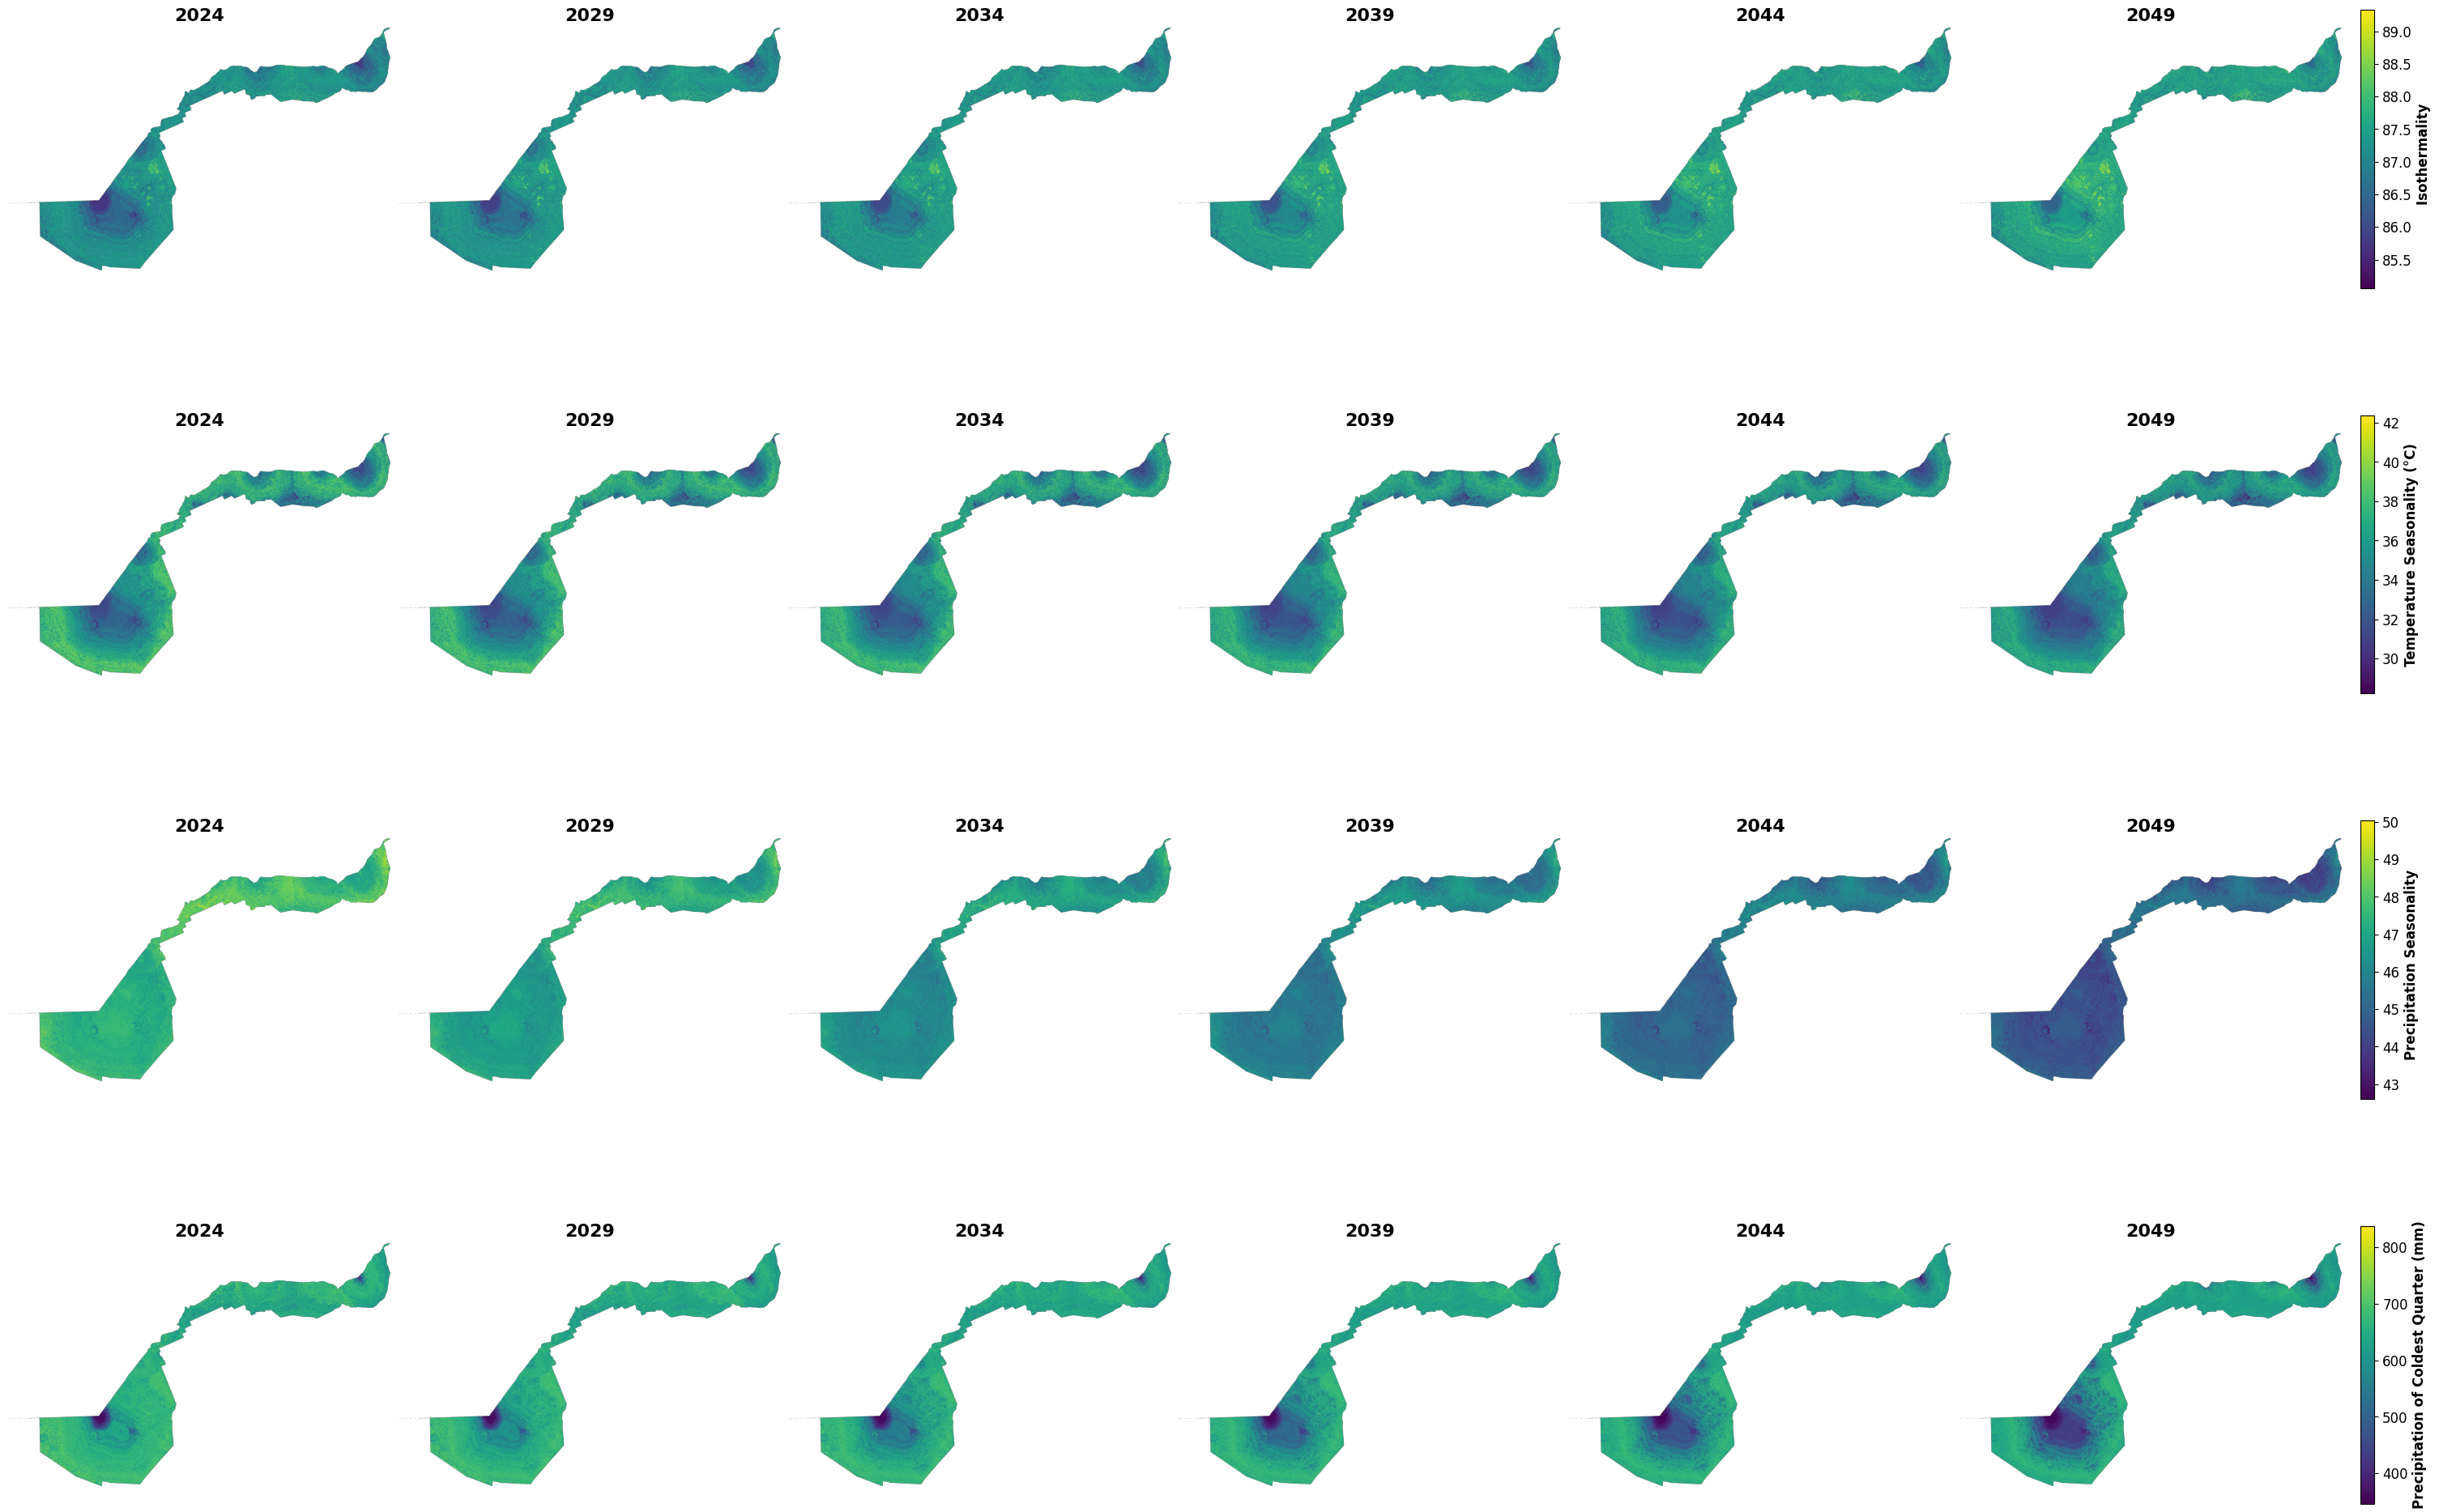

In [14]:
# Set up figure and axes
fig, axes = plt.subplots(n_vars, n_years, figsize=(5 * n_years, 5 * n_vars), constrained_layout=True)

# Ensure axes is always 2D array
if n_vars == 1:
    axes = np.expand_dims(axes, axis=0)
if n_years == 1:
    axes = np.expand_dims(axes, axis=1)

# Loop through each variable (by band index)
for band_index in range(n_vars):
    data_list = []

    # Read data for this band from each year's raster
    for year in sorted(bioclim_paths):
        with rasterio.open(bioclim_paths[year]) as src:
            band_data = src.read(band_index + 1)  
            band_data = np.where(band_data == src.nodata, np.nan, band_data)
            data_list.append(band_data)

            # Get the spatial resolution from raster metadata
            pixel_width, pixel_height = src.res 
            crs = src.crs  

    # Determine common color scale for the variable
    stacked = np.stack([np.nan_to_num(d, nan=np.nan) for d in data_list])
    vmin = np.nanmin(stacked)
    vmax = np.nanmax(stacked)

    # Plot for each year
    for col_index, (year, band_data) in enumerate(zip(sorted(bioclim_paths), data_list)):
        ax = axes[band_index, col_index]
        im = ax.imshow(band_data, cmap='viridis', vmin=vmin, vmax=vmax)
        ax.axis('off')
        ax.set_title(str(year), fontsize=16, fontweight="bold")
        
        # Add colorbar only on the last column of each row
        if col_index == n_years - 1:
            variable_name_with_unit = f"{bioclim_variable_labels[band_index]} {bioclim_units[band_index]}"
            cbar=fig.colorbar(im, ax=ax, shrink=0.7, label=variable_name_with_unit)
            cbar.set_label(variable_name_with_unit, fontsize=12, fontweight='bold')
            cbar.ax.tick_params(labelsize=12)

# Save the figure
plt.savefig("./refined_figures/bioclim_2024_2049.jpg", format='jpeg', dpi=300, bbox_inches='tight')
plt.show()